# Video injection A/B test sample



## Preamble

Hi 👋 

This is just a simple example of how an A/B test for a web project could be designed and how data analysts should analyze it once it is finished. I created this notebook cause during the HR process I was asked to show some examples of how I will construct this whole process. But I assume it could be helpful to other people too. So I will be grateful for any feedback. You can contact me [here](https://www.linkedin.com/in/ivan-kartavyi/).

## Introduction

Here I will design and then analyze the results of the A/B test. We are testing the hypothesis that adding a specific video on the first screen of the products list page affects user experience positively and increases the conversion rate for the key projects metrics.

This is not a real A/B test, the data was generated. The only goal is to show off what the process looks like. Do not pay attention to exact numbers in the results.

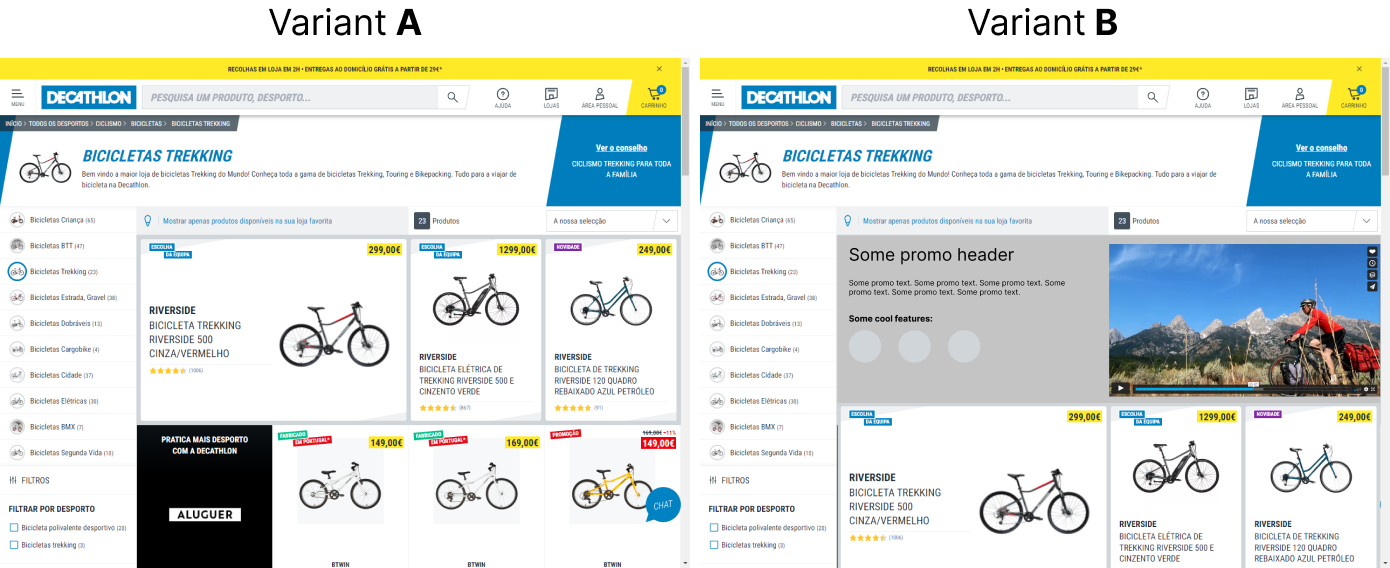

## Designing A/B test

### Defining metrics

So here we put some additional content and video about how this product could help you to bring new bright emotions into your life. We suppose that this will put some positive image in the customer's mind and will raise the conversion rate for purchases.

Ok, but at this point, we're still too far from the final stage of the funnel. And by this change, we do not affect this stage in a direct way. And this metric, also, could be not so sensitive in this case to show us a significant difference if it exists, or we will need tons of traffic which we might not have.

This means I, as a data analyst, have to choose some other metric that is strongly related to our business goals, but it should be more sensitive and closer to this step of the funnel.

In this case, according to the intent I mentioned before, I would choose the "Add to cart" user conversion rate.

Let's suppose that for the segment of traffic visited this page its current conversion rate = **7%**.

### Calculating how much users do we need

In [ ]:
# Importing necessary libraries for all calculations we will do in this workbook
import pandas as pd
import numpy as np
from statsmodels.stats import proportion
from statsmodels.stats.power import zt_ind_solve_power
import json

In [ ]:
# Let's define core test parameters
alpha = 0.05
beta = 0.2 

# Ok, beta is quite big. But let's suppose we do not have enough traffic, 
# so this is a better compromise for us to miss the difference than reject the 
# null hypothesis by mistake. 

# Just because the implementation of this feature costs a lot (video production), 
# if we scale it to other categories, I would like to be sure that it really works. 
# And we still have a chance to get more power if I have underestimated the effect. 

# Defining our expectations
current_cr = 0.07
expected_cr = 0.08

Then I have to calculate the number of users I need for my experiment. I can do it by my own and this would be like:
$$
n = \left( \frac{\sqrt{c\_cr \cdot (1 - c\_cr) } \cdot z_{1 - \alpha} + \sqrt{e\_cr \cdot (1 - e\_cr) } \cdot z_{1 - \beta} }{e\_cr - c\_cr}  \right)^2,
$$

Where $n$ is the number of observations, $\alpha$ is the error of the first kind, $\beta$ is the error of the second kind, $z_{1 - \alpha}, z_{1 - \beta}$ are the quantiles of the normal distribution.  $c\_cr$ — current_cr and $e\_cr$ — expected_cr

But it's easier to calculate it with zt_ind_solve_power() method from statsmodels. The only important thing here is that this model requires effect size to be standardized. Let's calculate it too.


In [ ]:
# Note that here we calculate it for propotion metrics. 
# For absolute values I will use another method.
st_effect = proportion.proportion_effectsize(
    prop1=current_cr,
    prop2=expected_cr
)
st_effect

-0.037986450108708936

In [ ]:
# Now calculating the number of observartions. I plan to use z-test in the end.

total_number_of_observations = zt_ind_solve_power(
    effect_size=st_effect,
    nobs1=None,
    alpha=alpha,
    power=(1 - beta),
    # I expect we will have an equal num of observations within branches
    ratio=1,
    alternative='smaller'
)

# Let's see how much users we need in each branch
total_number_of_observations / 2

4284.604359791662

In [ ]:
# Ok. Great. Suppose we have such amount and we will be finish our test 
# in a couple of weeks. 

# So let's move further.

### What we should track on the website


I must understand what data I will need to gather to clean the noisy data and make the correct conclusions. 

**1) "Fingerprints"**

Because I calculate the results within users' history (not sessions!) I'd love to have a real user "fingerprint" rather than one generated by  Google Analytics (clientId). At least when we can generate it, just because of all cookie issues, security settings, and cross-browser usage. We can use any proper approach, for instance — https://fingerprintjs.com/blog/audio-fingerprinting/.

**2) Video player events**

I want to track events of playback started, stopped, paused, % of the watch, and the actual time of watching. The actual time of watching is calculated incrementally once the video is being played and is in the user's view (easy to implement in GTM using JS).

I would love to have those events to make some post-analysis on how users interact with video and how we could change it. They do not affect A/B test results.

**3) % of time spent while the video was loading**

This will help for post-analysis as well. For example, to understand if we have to hide the video for some low-speed connections. If it affects the result or not.

**4) JS errors**

Any JS errors caused by inserted promo objects and made them inaccessible for the end-user.

**5) GA Enhanced eCommerce, of course.**

To make it easier, in the dataset I will have some simple events that user seen the product and added product to cart. But in the real-life it should be GA Enhanced eCommerce.

**6) Event once our promo block becomes visible for a specific user.**

In the dataset, I will have only those events, which will help me in the A/B test results calculation. Those events I mentioned as "for post-analysis" I will skip just to simplify understanding of the A/B test calculation. But in real-life I will have to analyze them as well since I will have the real, not generated randomly, data.

## Getting the result

In [ ]:
# Here I will load, clean data and calculate the result of our A/B test.
# Let's load generated streaming data first
with open('streaming_data.json', 'r') as file:
  df = pd.DataFrame(json.load(file))

df.head()

,type,comment,timestamp,user_id,branch
0,pageview,The page we testing,1.649431e+12,1649431118.485429_92,B
1,product_shown,Some random product name,1.649434e+12,1649431118.485429_92,B
2,pageview,The page we testing,1.649431e+12,1649431119.485429_2,B
3,product_shown,Some random product name,1.649432e+12,1649431119.485429_2,B
4,promo_block_shown,,1.649435e+12,1649431119.485429_2,B


In [ ]:
#  Now checking what events do we got here
df['type'].unique()

array(['pageview', 'product_shown', 'promo_block_shown',
       'product_added_to_cart', 'JS_error'], dtype=object)

In [ ]:
# Ok, now I will clear the data from events for users got JS_error which didn't 
# allow us to show them promo_block in a proper way.
block_id  = df[df['type']=='JS_error']['user_id'].unique()
len(block_id)

186

In [ ]:
# Excluding those from block_id
df = df[~(df['user_id'].isin(block_id))]

In [ ]:
# Excluding those who hadn't seen any product or promo_block
who_seen_promo_or_product = df[df['type'].isin(['product_shown', 'promo_block_shown'])]['user_id']
more_ids_to_exclude = df[~(df['user_id'].isin(who_seen_promo_or_product))]['user_id']
len(more_ids_to_exclude.unique())

5238

In [ ]:
# Oh, a big number. It's valuable. Excluding.
df = df[~(df['user_id'].isin(more_ids_to_exclude))]

In [ ]:
# We might also have those in variant B who had seen products, but  hadn't seen promo block:
# scrolled too fast or maybe som tech issues we didn't catch.
# Let's exclude them as well
ids_to_invert = df[(df['branch'] == 'B') & (df['type']=='promo_block_shown')]['user_id']
users_from_B_with_anomalies = df[(df['branch']=='B') & ~(df['user_id'].isin(ids_to_invert))]['user_id']
df = df[~df['user_id'].isin(users_from_B_with_anomalies)]

In [ ]:
# Now let's calculate the results
results_df = df.pivot_table(index='branch', values='user_id', columns=['type'], aggfunc=pd.Series.nunique)
results_df = results_df.fillna(0)

# Calculating totals
total_df = df.groupby('branch')\
.agg({'user_id':pd.Series.nunique})\
.rename(columns={'user_id':'total_id_amount'})

results_df = pd.merge(results_df, total_df, left_index=True, right_index=True)
results_df['add_to_cart_cr'] = results_df['product_added_to_cart'] / results_df['total_id_amount']
results_df


,pageview,product_added_to_cart,product_shown,promo_block_shown,total_id_amount,add_to_cart_cr
branch,,,,,,
A,5227.0,486.0,5227.0,0.0,5227,0.092979
B,6993.0,763.0,3841.0,6993.0,6993,0.109109


In [ ]:
# Our calculated effect is rather bigger than we expected.
results_df.loc['B']['add_to_cart_cr'] - results_df.loc['A']['add_to_cart_cr']

0.016130344999677304

In [ ]:
# Now let's calculate the p-value
observations = results_df['total_id_amount'].values
successes = results_df['product_added_to_cart'].values

z_obs, p_val = proportion.proportions_ztest(
    count=successes,
    nobs=observations,
    value=0,
    alternative='smaller'
)

print(f'zstats is {z_obs:.3}')
result_str = 'can' if p_val < alpha else 'can\'t'
print(f'p-value is {p_val:.3} and we {result_str} reject the null hypothesis')

zstats is -2.91
p-value is 0.00179 and we can reject the null hypothesis


In [ ]:
# Good. So p-value lower. Let's calculate the power value then
cr_a, cr_b = results_df['add_to_cart_cr']
n_a, n_b = results_df['total_id_amount']

effect = proportion.proportion_effectsize(
    prop1=cr_a,
    prop2=cr_b
)
power = zt_ind_solve_power(
    effect_size=effect,
    nobs1=n_a,
    alpha=alpha,
    power=None,
    ratio=n_b/n_a,
    alternative='smaller'
)

print(f'The power is {power}')

The power is 0.9005105791642225


## Сonclusion

This means I can reject the null hypothesis and state that variant B works better. If it was a real test and a real result, we shall do the following things:

1) research the  additional data about  how this test affected some detailed segments of traffic I mentioned before;

2) try to scale this approach over a significant group of categories and come up again with the new A/B test;

3) if we wouldn't manage to do the 2nd option fast, then we need to kick off this test a bit later one more time to verify the result for sure.

# P.S.

I hope this example was helpful and brought you some insights or new thoughts. I would be grateful for any feedback. Please get in touch with me on LinkedIn: https://www.linkedin.com/in/ivan-kartavyi/.

And if you found any mistakes, please let me know.

See you, stay tuned.